# E-Commerce Transactions Data Science Project


## 1. Data Gathering

The dataset used in this project is an **E-Commerce Transactions Dataset** obtained from Kaggle.
The dataset contains transactional data that simulates real-world online retail activity.

**Dataset Link:**
https://www.kaggle.com/datasets/smayanj/e-commerce-transactions-dataset



## Dataset Description

The **E-Commerce Transactions Dataset** is a synthetic dataset designed to represent real-world
online shopping transactions. It consists of **50,000 records**, where each record corresponds
to a single transaction made by a customer on an e-commerce platform.

The dataset includes information about customers, product categories, transaction amounts,
payment methods, and transaction dates. It contains both numerical and categorical attributes,
making it suitable for exploratory data analysis and machine learning tasks.

### Dataset Characteristics
- Domain: E-Commerce / Retail
- Type: Transactional dataset
- Format: CSV
- Nature: Synthetic but realistic


!pip install kagglehub

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [6]:
path = kagglehub.dataset_download("smayanj/e-commerce-transactions-dataset")

print("Dataset path:", path)


Dataset path: C:\Users\habia\.cache\kagglehub\datasets\smayanj\e-commerce-transactions-dataset\versions\1


In [7]:
os.listdir(path)

['ecommerce_transactions.csv']

In [8]:
df = pd.read_csv(os.path.join(path, "ecommerce_transactions.csv"))
df.head()

,Transaction_ID,User_Name,Age,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29


## 2. Data Assessment

After gathering the dataset, an initial assessment was performed to evaluate the data quality.
This assessment includes checking the dataset structure, identifying missing values, detecting
duplicate records, and visually inspecting the data for potential outliers.


In [10]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    50000 non-null  int64  
 1   User_Name         50000 non-null  object 
 2   Age               50000 non-null  int64  
 3   Country           50000 non-null  object 
 4   Product_Category  50000 non-null  object 
 5   Purchase_Amount   50000 non-null  float64
 6   Payment_Method    50000 non-null  object 
 7   Transaction_Date  50000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 3.1+ MB


In [11]:
# Display statistical summary of numerical columns
df.describe()

,Transaction_ID,Age,Purchase_Amount
count,50000.000000,50000.000000,50000.000000
mean,25000.500000,43.968680,503.159793
std,14433.901067,15.260578,286.563558
min,1.000000,18.000000,5.040000
25%,12500.750000,31.000000,255.450000
50%,25000.500000,44.000000,503.110000
75%,37500.250000,57.000000,751.162500
max,50000.000000,70.000000,999.980000


In [12]:
# Check for missing (null) values
df.isnull().sum()

Transaction_ID      0
User_Name           0
Age                 0
Country             0
Product_Category    0
Purchase_Amount     0
Payment_Method      0
Transaction_Date    0
dtype: int64

In [13]:
# Check for duplicate rows
df.duplicated().sum()

0

In [14]:
print(df.columns)


Index(['Transaction_ID', 'User_Name', 'Age', 'Country', 'Product_Category',
       'Purchase_Amount', 'Payment_Method', 'Transaction_Date'],
      dtype='object')


### Outlier Detection

Visual inspection was used to detect potential outliers in numerical features such as
purchase amount and customer age.


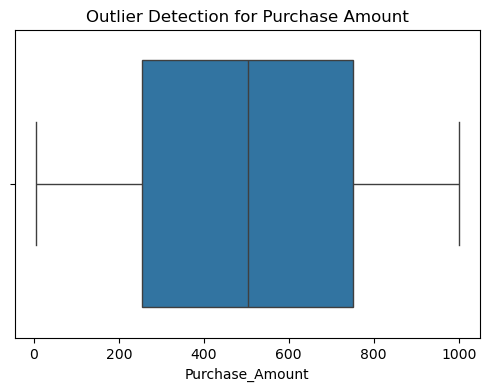

In [16]:
# Boxplot for Purchase Amount
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Purchase_Amount"])
plt.title("Outlier Detection for Purchase Amount")
plt.show()


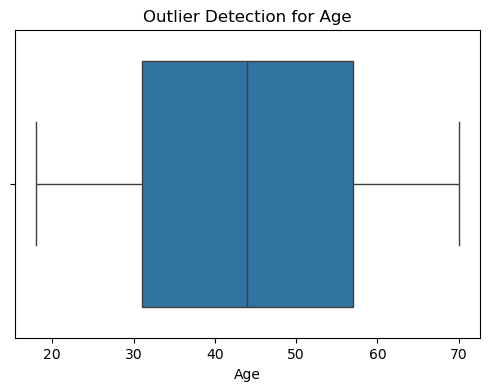

In [17]:
# Boxplot for Age
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.title("Outlier Detection for Age")
plt.show()


## 2. Project Objective

The main objective of this project is to analyze customer purchasing behavior in an
e-commerce environment using transactional data.

The problem addressed in this project is understanding how customers interact with
different product categories, payment methods, and purchase amounts.

### Project Objectives:
- Analyze customer spending patterns
- Identify popular product categories
- Explore payment method preferences
- Group customers based on purchasing behavior using data science techniques

## 3. Data Cleaning and Preparation

This step focuses on improving data quality by handling missing values, removing
duplicate records, addressing outliers, and converting the dataset into a usable
format suitable for analysis and modeling.


In [20]:
# Check missing values
df.isnull().sum()

Transaction_ID      0
User_Name           0
Age                 0
Country             0
Product_Category    0
Purchase_Amount     0
Payment_Method      0
Transaction_Date    0
dtype: int64

In [21]:
# Drop rows with missing values (if any)
df.dropna(inplace=True)

In [22]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [24]:
# Convert Transaction_Date to datetime
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

In [25]:
# Detect and remove outliers using IQR for Purchase Amount
Q1 = df["Purchase_Amount"].quantile(0.25)
Q3 = df["Purchase_Amount"].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df["Purchase_Amount"] >= Q1 - 1.5 * IQR) &
    (df["Purchase_Amount"] <= Q3 + 1.5 * IQR)
]

## 4. Data Visualization

Various visualization techniques were used to explore the dataset and identify
patterns and trends in customer behavior.

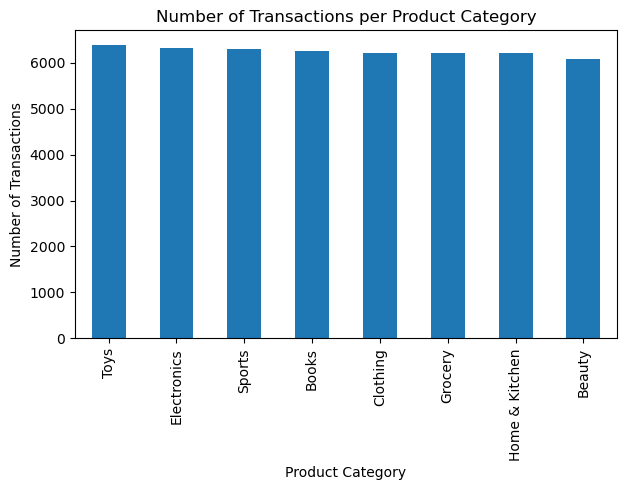

In [27]:
plt.figure(figsize=(7,4))
df["Product_Category"].value_counts().plot(kind="bar")
plt.title("Number of Transactions per Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.show()

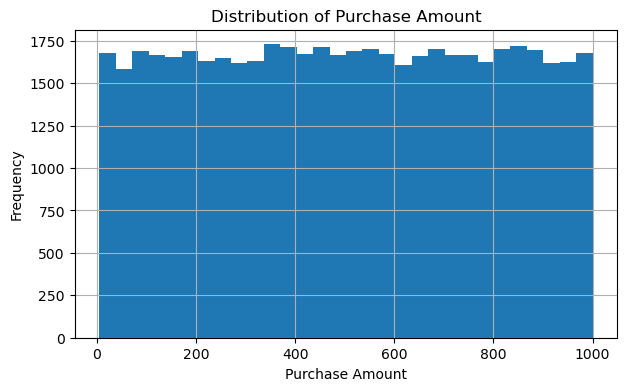

In [28]:
plt.figure(figsize=(7,4))
df["Purchase_Amount"].hist(bins=30)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

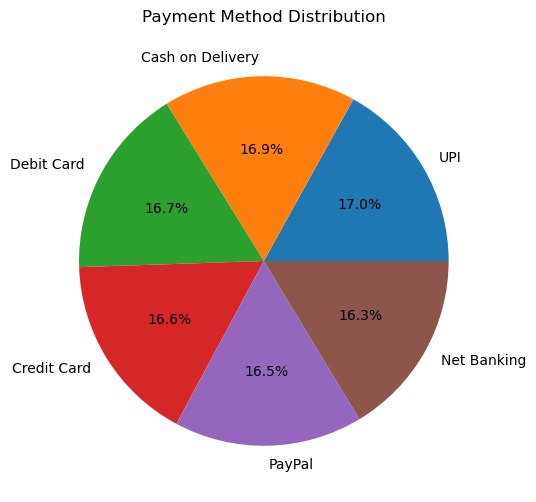

In [29]:
plt.figure(figsize=(6,6))
df["Payment_Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

## 5. Applied Data Science Technique

In this project, **K-Means Clustering** was applied to group customers based on their
purchasing behavior.

### Why K-Means?
- Suitable for unsupervised learning
- Helps identify customer segments
- Works well with numerical transactional data

In [34]:
# Select numerical features for clustering
X = df[["Purchase_Amount", "Age"]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

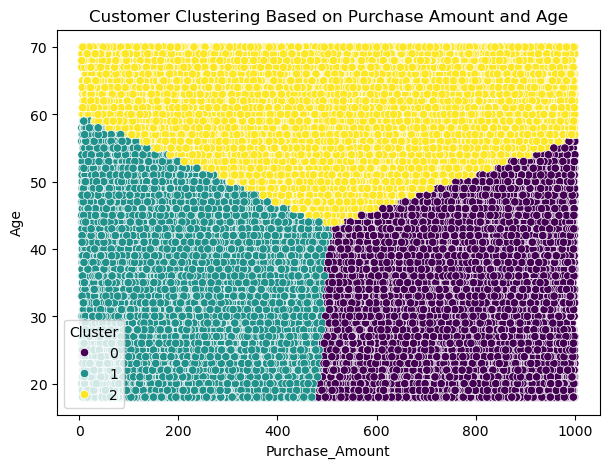

In [41]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["Purchase_Amount"],
    y=df["Age"],
    hue=df["Cluster"],
    palette="viridis"
)
plt.title("Customer Clustering Based on Purchase Amount and Age")
plt.show()

## 6. Data Insights

Based on the analysis and clustering results, the following insights were obtained:

- Certain product categories have significantly higher transaction volumes, indicating
  strong customer demand.
- Most customers prefer specific payment methods, which can help businesses optimize
  payment options.
- Purchase amounts are mostly concentrated within a specific range, with a few high-value
  transactions acting as outliers.
- K-Means clustering successfully grouped customers into distinct segments based on
  spending behavior and age.
- These customer segments can be used for targeted marketing and personalized promotions.